## Empirical Analysis vs Monte Carlo Simulation

### Empirical Analysis (Real Data)

**Purpose:**
- Learn about an unknown Data Generating Process (DGP) using observed data  
- Estimate parameters and test hypotheses  
- Draw conclusions about real-world relationships  

---

### Monte Carlo Simulation (Synthetic Data)

**Purpose:**
- Evaluate statistical methods under a known DGP  
- Study properties of estimators (bias, variance) and tests (size, power)  
- Assess reliability of estimation and inference procedures  

## Empirical Workflow: From Data → Joint DGP → Estimation → Hypothesis Testing (Two Variables)

### Purpose

The purpose of this workflow is to:

- Use observed data to learn about the unknown Data Generating Process (DGP)  
- Estimate key parameters such as means and covariance  
- Test hypotheses about relationships between variables  
- Draw statistically valid and economically meaningful conclusions  

This framework is the foundation of empirical analysis in econometrics and statistics.

---

| Step | Action | Concept | Formula | Purpose | Reference |
|------|--------|--------|---------|---------|-----------|
| 1 | Observe data | Sample | $(r_i, x_i), \; i=1,\dots,20$ | Collect joint observations | Casella & Berger (2002), Ch.1 |
| 2 | Recognize origin | DGP (true, unknown) | — | Acknowledge data come from a joint process | Hayashi (2000), Ch.1 |
| 3 | Specify model | Joint DGP (assumed) | $\begin{pmatrix} r_i \\ x_i \end{pmatrix} \sim \text{i.i.d. } (\mu, \Sigma)$ | Impose probabilistic structure | Wooldridge (2010), Ch.2 |
| 4 | Define parameters | Unknowns | $\mu = \begin{pmatrix}\mu_r \\ \mu_x\end{pmatrix}$, $\Sigma = \begin{pmatrix}\sigma_r^2 & \sigma_{rx} \\ \sigma_{rx} & \sigma_x^2\end{pmatrix}$ | Characterize distribution and dependence | Casella & Berger (2002), Ch.3 |
| 5 | Estimate parameters | Estimation | $\hat{\mu}, \hat{\Sigma}$ from data | Learn parameters from sample | Wooldridge (2010), Ch.2 |
| 6 | Construct model | Fitted DGP | $(r_i, x_i) \sim (\hat{\mu}, \hat{\Sigma})$ | Approximate the true DGP | Hayashi (2000), Ch.1 |
| 7 | Formulate hypothesis | Restriction | $H_0: \sigma_{rx} = 0$ or $H_0: \beta = 0$ | State testable claim about relationship | Wooldridge (2010), Ch.3 |
| 8 | Compute statistic | Inference | correlation or regression t-stat | Quantify evidence against $H_0$ | Casella & Berger (2002), Ch.9 |
| 9 | Make decision | Hypothesis test | p-value / critical value | Decide to reject or not reject $H_0$ | Wooldridge (2010), Ch.4 |
| 10 | Interpret results | Economic meaning | — | Translate statistical result into insight | Hayashi (2000), Ch.2 |

---

### Key Upgrade (with references)

- One variable → focus on mean $\mu$  
- Two variables → focus on mean $\mu$ **and covariance $\Sigma$**  

This follows from multivariate distribution theory:

- Univariate: $(\mu, \sigma^2)$  
- Multivariate: $(\mu, \Sigma)$  

---

### Supporting References

- Casella & Berger (2002), Chapter 3 (Multivariate Distributions)  
- Hayashi (2000), Chapter 1 (Joint distributions and moments)  
- Wooldridge (2010), Chapter 2 (Random sampling and moments)  

## Get data

In [3]:
# Step 1: Observe data (sample of returns)

import numpy as np
import pandas as pd

# Fix randomness
np.random.seed(42)

# Generate 20 observations for two variables
# r_i = returns
# x_i = another variable (e.g., market factor)

r = np.random.normal(loc=0.07, scale=0.12, size=20)
x = np.random.normal(loc=0.05, scale=0.10, size=20)

# Put into a table
df = pd.DataFrame({
    'r_i': r,
    'x_i': x
})

# Show the data
print(df)

         r_i       x_i
0   0.129606  0.196565
1   0.053408  0.027422
2   0.147723  0.056753
3   0.252764 -0.092475
4   0.041902 -0.004438
5   0.041904  0.061092
6   0.259506 -0.065099
7   0.162092  0.087570
8   0.013663 -0.010064
9   0.135107  0.020831
10  0.014390 -0.010171
11  0.014112  0.235228
12  0.099035  0.048650
13 -0.159594 -0.055771
14 -0.136990  0.132254
15  0.002525 -0.072084
16 -0.051540  0.070886
17  0.107710 -0.145967
18 -0.038963 -0.082819
19 -0.099476  0.069686


## Step 2: The Data Generating Process (DGP) for Two Variables

| Element | Description |
|--------|------------|
| Data | Observed pairs $(r_i, x_i)$ |
| Question | How are these variables generated together? |
| True DGP | Unknown joint distribution |
| Assumed DGP | $\begin{pmatrix} r_i \\ x_i \end{pmatrix} \sim \text{i.i.d. } (\mu, \Sigma)$ |
| Mean vector | $\mu = \begin{pmatrix} \mu_r \\ \mu_x \end{pmatrix}$ |
| Covariance matrix | $\Sigma = \begin{pmatrix} \sigma_r^2 & \sigma_{rx} \\ \sigma_{rx} & \sigma_x^2 \end{pmatrix}$ |
| New element | $\sigma_{rx}$ = covariance (relationship) |
| Interpretation | Variables are generated jointly, not separately |
| Assumption | Each pair $(r_i, x_i)$ is independent across $i$, but variables within each pair may be correlated |
| Goal | Capture both levels and dependence |

---

### Explanation

Instead of modeling $r_i$ alone, we now model the pair:

$\begin{pmatrix} r_i \\ x_i \end{pmatrix}$

This means:

- Each observation is a **joint draw**
- The distribution includes:
  - Means: $\mu_r, \mu_x$
  - Variances: $\sigma_r^2, \sigma_x^2$
  - Covariance: $\sigma_{rx}$

---

### Key Insight

👉 The covariance $\sigma_{rx}$ is the FIRST measure of relationship  

- $\sigma_{rx} > 0$ → move together  
- $\sigma_{rx} < 0$ → move oppositely  
- $\sigma_{rx} = 0$ → no linear relationship  

---

### Why this matters

This is the foundation for:

- Correlation  
- Regression  
- VAR models  

---

### References

- Hayashi (2000), Chapter 1  
- Wooldridge (2010), Chapter 2  
- Casella & Berger (2002), Chapter 3  

## Step 3: Specify the Joint DGP (Model)

| Element | Description |
|--------|------------|
| Input | Observed data $(r_i, x_i)$ |
| True DGP | Unknown joint process generating the data |
| Assumed model | $(r_i, x_i) \sim \text{i.i.d. } (\mu, \Sigma)$ |
| Structure | Each observation is a joint draw from the same distribution |
| Independence | Observations are independent across $i$ |
| Identical distribution | All observations share the same $(\mu, \Sigma)$ |
| Key feature | Variables may be correlated within each observation |
| Purpose | Impose a probabilistic structure on the data |
| Output | A formal model describing how data are generated |

---

### Explanation

Since the true DGP is unknown, we **specify a model**:

$(r_i, x_i) \sim \text{i.i.d. } (\mu, \Sigma)$

This means:

- Each pair $(r_i, x_i)$ is generated jointly  
- The distribution is the same across all observations  
- Observations are independent across $i$  

---

### Key Insight

👉 This step introduces the **joint distribution**

- One variable → $(\mu, \sigma^2)$  
- Two variables → $(\mu, \Sigma)$  

---

### Important Clarification

- “Joint” → dependence within each pair $(r_i, x_i)$  
- “i.i.d.” → independence across different observations  

---

### Why this step matters

👉 This is where data become a **statistical model**  
👉 Everything after (estimation, testing) depends on this assumption  

---

### References

- Wooldridge (2010), Chapter 2  
- Hayashi (2000), Chapter 1  
- Casella & Berger (2002), Chapter 3  

In [7]:
# Step 3: Estimate mean vector and covariance matrix

# Mean vector
mu_hat = df.mean()

print("Estimated mean vector (mu_hat):")
print(mu_hat)

# Covariance matrix
Sigma_hat = df.cov()

print("\nEstimated covariance matrix (Sigma_hat):")
print(Sigma_hat)

Estimated mean vector (mu_hat):
r_i    0.101084
x_i    0.047429
dtype: float64

Estimated covariance matrix (Sigma_hat):
          r_i       x_i
r_i  0.011422  0.004063
x_i  0.004063  0.009401


## Step 4: Define Parameters of the Joint DGP

| Element | Description |
|--------|------------|
| Input | Assumed joint DGP: $(r_i, x_i) \sim \text{i.i.d. } (\mu, \Sigma)$ |
| Mean vector | $\mu = \begin{pmatrix} \mu_r \\ \mu_x \end{pmatrix}$ |
| Variances | $\sigma_r^2$ (variance of $r_i$), $\sigma_x^2$ (variance of $x_i$) |
| Covariance | $\sigma_{rx} = \text{Cov}(r_i, x_i)$ |
| Covariance matrix | $\Sigma = \begin{pmatrix} \sigma_r^2 & \sigma_{rx} \\ \sigma_{rx} & \sigma_x^2 \end{pmatrix}$ |
| Interpretation (means) | Average level of each variable |
| Interpretation (variances) | Variability (risk) of each variable |
| Interpretation (covariance) | Linear relationship between variables |
| Key role | Fully characterizes the joint distribution |
| Status | Parameters are unknown and must be estimated |

---

### Explanation

Given the assumed DGP:

$(r_i, x_i) \sim \text{i.i.d. } (\mu, \Sigma)$

we now define its parameters:

- $\mu_r$ = expected value of $r_i$  
- $\mu_x$ = expected value of $x_i$  

- $\sigma_r^2$ = variance of $r_i$  
- $\sigma_x^2$ = variance of $x_i$  

- $\sigma_{rx}$ = covariance between $r_i$ and $x_i$  

Together, these form the covariance matrix:

$\Sigma = \begin{pmatrix} \sigma_r^2 & \sigma_{rx} \\ \sigma_{rx} & \sigma_x^2 \end{pmatrix}$

---

### Key Insight

👉 The covariance $\sigma_{rx}$ is the **first formal measure of relationship**

- $\sigma_{rx} > 0$ → move together  
- $\sigma_{rx} < 0$ → move in opposite directions  
- $\sigma_{rx} = 0$ → no linear relationship  

---

### Why this step matters

👉 This step defines **what needs to be estimated next**  
👉 It bridges:
- DGP (structure) → Estimation (numbers)

---

### References

- Casella & Berger (2002), Chapter 3  
- Hayashi (2000), Chapter 1  
- Wooldridge (2010), Chapter 2  

## Step 5: Estimate Parameters from Data

| Element | Description |
|--------|------------|
| Input | Observed data $(r_i, x_i)$ |
| Assumed DGP | $(r_i, x_i) \sim \text{i.i.d. } (\mu, \Sigma)$ |
| Parameters | $\mu = \begin{pmatrix} \mu_r \\ \mu_x \end{pmatrix}$, $\Sigma = \begin{pmatrix} \sigma_r^2 & \sigma_{rx} \\ \sigma_{rx} & \sigma_x^2 \end{pmatrix}$ |
| Estimation (mean) | $\hat{\mu} = \begin{pmatrix} \hat{\mu}_r \\ \hat{\mu}_x \end{pmatrix}$ where $\hat{\mu}_r = \frac{1}{n}\sum r_i$, $\hat{\mu}_x = \frac{1}{n}\sum x_i$ |
| Estimation (covariance) | $\hat{\Sigma} = \frac{1}{n-1} \sum (Y_i - \hat{\mu})(Y_i - \hat{\mu})'$ |
| Output | Estimated parameters $\hat{\mu}, \hat{\Sigma}$ |
| Interpretation | Numerical summary of location, variability, and relationship |
| Purpose | Learn unknown parameters of the DGP from data |

---

### Explanation

We now move from theory to data.

Using the sample, we estimate:

- Mean of each variable:
  - $\hat{\mu}_r$ = average return  
  - $\hat{\mu}_x$ = average of $x$  

- Covariance matrix:
  - Variances: $\hat{\sigma}_r^2$, $\hat{\sigma}_x^2$  
  - Covariance: $\hat{\sigma}_{rx}$  

---

### Key Insight

👉 This is where the **unknown DGP becomes measurable**

- Before: $(\mu, \Sigma)$ unknown  
- Now: $(\hat{\mu}, \hat{\Sigma})$ estimated  

---

### Why this step matters

👉 Everything after (hypothesis testing, regression, VAR) depends on these estimates  

---

### References

- Wooldridge (2010), Chapter 2  
- Hayashi (2000), Chapter 1  
- Casella & Berger (2002), Chapter 3  

In [8]:
# Step 5: Estimate parameters

# Mean vector
mu_hat = df.mean()

print("Estimated mean vector (mu_hat):")
print(mu_hat)

# Covariance matrix
Sigma_hat = df.cov()

print("\nEstimated covariance matrix (Sigma_hat):")
print(Sigma_hat)

Estimated mean vector (mu_hat):
r_i    0.101084
x_i    0.047429
dtype: float64

Estimated covariance matrix (Sigma_hat):
          r_i       x_i
r_i  0.011422  0.004063
x_i  0.004063  0.009401


## Step 6: Construct the Estimated DGP

| Element | Description |
|--------|------------|
| Input | Estimated parameters $\hat{\mu}, \hat{\Sigma}$ |
| Model | $(r_i, x_i) \sim (\hat{\mu}, \hat{\Sigma})$ |
| Mean vector | $\hat{\mu} = \begin{pmatrix} \hat{\mu}_r \\ \hat{\mu}_x \end{pmatrix}$ |
| Covariance matrix | $\hat{\Sigma} = \begin{pmatrix} \hat{\sigma}_r^2 & \hat{\sigma}_{rx} \\ \hat{\sigma}_{rx} & \hat{\sigma}_x^2 \end{pmatrix}$ |
| Interpretation | Best approximation of the true DGP based on data |
| Role | Bridge between estimation and inference |
| Status | Fully specified statistical model |

---

### Explanation

After estimating parameters in Step 5, we now **construct the estimated DGP**:

$(r_i, x_i) \sim (\hat{\mu}, \hat{\Sigma})$

This means:

- We treat $\hat{\mu}$ and $\hat{\Sigma}$ as the **best available description** of the data  
- The model now fully describes:
  - Average behavior (means)  
  - Risk (variances)  
  - Relationship (covariance)  

---

### Key Insight

👉 You now have a **complete probabilistic model of your data**

---

### Why this step matters

👉 This is the model you will:
- Test (Step 7–9)  
- Interpret (Step 10)  
- Use for prediction or further analysis  

---

### References

- Hayashi (2000), Chapter 1  
- Wooldridge (2010), Chapter 2  
- Casella & Berger (2002), Chapter 3  

In [9]:
print("Estimated DGP:")

print("\nMean vector (mu_hat):")
print(mu_hat)

print("\nCovariance matrix (Sigma_hat):")
print(Sigma_hat)

print("\nInterpretation:")
print("Data are modeled as draws from a distribution with these estimated parameters.")

Estimated DGP:

Mean vector (mu_hat):
r_i    0.101084
x_i    0.047429
dtype: float64

Covariance matrix (Sigma_hat):
          r_i       x_i
r_i  0.011422  0.004063
x_i  0.004063  0.009401

Interpretation:
Data are modeled as draws from a distribution with these estimated parameters.


## Step 7: Formulate Hypothesis

| Element | Description |
|--------|------------|
| Input | Estimated DGP $(\hat{\mu}, \hat{\Sigma})$ |
| Focus | Relationship between variables |
| Parameter of interest | $\sigma_{rx}$ (covariance) or $\rho$ (correlation) |
| Null hypothesis | $H_0: \sigma_{rx} = 0$ |
| Alternative hypothesis | $H_1: \sigma_{rx} \neq 0$ |
| Equivalent form | $H_0: \rho = 0$ |
| Interpretation | No linear relationship between $r_i$ and $x_i$ |
| Goal | Test whether observed relationship is real or due to randomness |

---

### Explanation

After estimating the joint DGP, we now ask a **testable question**:

👉 *Are the two variables related?*

This becomes a hypothesis:

- $H_0$: no relationship  
- $H_1$: there is a relationship  

We focus on:
- Covariance $\sigma_{rx}$  
- Or correlation $\rho$

---

### Key Insight

👉 A hypothesis is a **restriction on the DGP parameters**

- DGP says: $\sigma_{rx}$ exists  
- Hypothesis says: $\sigma_{rx} = 0$

---

### Why this step matters

👉 This is where **theory or research questions enter the model**

---

### References

- Wooldridge (2010), Chapter 3  
- Casella & Berger (2002), Chapter 8  
- Hayashi (2000), Chapter 2  

In [10]:
# Sample correlation (what we will test)

corr = df.corr().loc['r_i', 'x_i']

print("Sample correlation between r and x:", corr)

Sample correlation between r and x: 0.39209304390805744


## Step 8: Compute Test Statistic

| Element | Description |
|--------|------------|
| Input | Sample data $(r_i, x_i)$ |
| Hypothesis | $H_0: \rho = 0$ (no correlation) |
| Statistic | Sample correlation $r$ |
| Test statistic | $t = \frac{r \sqrt{n-2}}{\sqrt{1 - r^2}}$ |
| Distribution | $t \sim t_{n-2}$ under $H_0$ |
| Degrees of freedom | $n - 2$ |
| Output | $t$-value and p-value |
| Purpose | Measure how far data deviate from $H_0$ |

---

### Explanation

We compute a statistic that evaluates how consistent the observed data are with the null hypothesis.

Steps:

- Compute the sample correlation $r$  
- Transform it into a $t$-statistic  
- Compare it with a reference distribution  

---

### What is the t-statistic?

The t-statistic is defined as:

$t = \frac{r \sqrt{n-2}}{\sqrt{1 - r^2}}$

It represents:

- A standardized measure of how far the observed correlation is from zero  
- A quantity that adjusts for both sample size and variability  

Interpretation:

- A large absolute value of $t$ indicates strong evidence against $H_0$  
- A small absolute value of $t$ indicates consistency with $H_0$  

---

### What is the reference distribution?

Under the null hypothesis:

$t \sim t_{n-2}$

This means:

- The t-statistic follows a t-distribution with $(n-2)$ degrees of freedom  
- This distribution describes the behavior of the statistic when $H_0$ is true  

Role:

- Provides a benchmark to determine whether the observed $t$ is unusually large  
- Allows us to compute probabilities associated with the observed statistic  

---

### What is the p-value?

The p-value is defined as:

$p\text{-value} = P(|T| \ge |t_{\text{obs}}| \mid H_0)$

It represents:

- The probability of observing a test statistic at least as extreme as the one obtained  
- This probability is computed under the assumption that $H_0$ is true  

Interpretation:

- A small p-value indicates that the observed result is unlikely under $H_0$  
- A large p-value indicates that the result is plausible under $H_0$  

---

### Key Insight

- The test statistic measures distance from the null hypothesis  
- The reference distribution translates this distance into a probability  
- The p-value summarizes the strength of evidence against $H_0$  

---

### References

- Wooldridge (2010), Chapter 4  
- Casella & Berger (2002), Chapter 9  
- Hayashi (2000), Chapter 2  

In [13]:
import numpy as np
from scipy import stats

# Number of observations
n = len(df)

# Sample correlation
r = df['r_i'].corr(df['x_i'])

# Compute t-statistic
t_stat = r * np.sqrt((n - 2) / (1 - r**2))

# Two-sided p-value
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-2))

print("Sample correlation (r):", r)
print("t-statistic:", t_stat)
print("p-value:", p_value)

Sample correlation (r): 0.3920930439080575
t-statistic: 1.8083092423229135
p-value: 0.08729633132793824


## Step 9: Make Decision

| Element | Description |
|--------|------------|
| Input | Test statistic $t$ and p-value |
| Hypothesis | $H_0: \rho = 0$ |
| Significance level | $\alpha$ (e.g., 0.05) |
| Decision rule (p-value) | Reject $H_0$ if $p$-value $< \alpha$ |
| Decision rule (critical value) | Reject $H_0$ if $|t| > t_{\alpha/2, n-2}$ |
| Output | Reject or fail to reject $H_0$ |
| Purpose | Convert statistical evidence into a formal decision |

---

### Explanation

At this step, we use the results from Step 8 to decide whether the data provide enough evidence against the null hypothesis.

Two equivalent approaches can be used:

1. p-value approach  
2. critical value approach  

---

### p-value approach

Decision rule:

- Reject $H_0$ if the p-value is less than the chosen significance level $\alpha$  
- Otherwise, fail to reject $H_0$

Interpretation:

- Small p-value indicates strong evidence against $H_0$  
- Large p-value indicates insufficient evidence against $H_0$  

---

### Critical value approach

Decision rule:

- Compute the critical value from the $t$-distribution  
- Reject $H_0$ if $|t|$ exceeds this threshold  

Interpretation:

- If the test statistic falls in the tail of the distribution, it is considered unlikely under $H_0$  

---

### Important clarification

- “Reject $H_0$” does not mean $H_0$ is false with certainty  
- “Fail to reject $H_0$” does not mean $H_0$ is true  

The decision is based on probability, not certainty.

---

### Role of the significance level

- $\alpha$ represents the tolerance for Type I error  
- Common choices: 0.10, 0.05, 0.01  

---

### Key Insight

- Step 8 produces evidence  
- Step 9 converts that evidence into a formal decision  

---

### References

- Wooldridge (2010), Chapter 4  
- Casella & Berger (2002), Chapter 9  
- Hayashi (2000), Chapter 2  

In [14]:
# Step 9: Decision

alpha = 0.05  # significance level

if p_value < alpha:
    decision = "Reject H0"
else:
    decision = "Fail to reject H0"

print("Decision:", decision)

Decision: Fail to reject H0


## Step 10: Interpret Results

| Element | Description |
|--------|------------|
| Input | Decision from Step 9 (Reject or Fail to Reject $H_0$) |
| Hypothesis | $H_0: \rho = 0$ (no relationship) |
| Case 1 | Reject $H_0$ |
| Interpretation (Case 1) | There is statistical evidence of a relationship between $r_i$ and $x_i$ |
| Case 2 | Fail to reject $H_0$ |
| Interpretation (Case 2) | There is insufficient evidence of a relationship between $r_i$ and $x_i$ |
| Key point | Statistical significance does not imply causality |
| Output | Economic and statistical conclusion |

---

### Explanation

This step translates the statistical decision into a meaningful conclusion.

If we reject $H_0$:

- The data provide evidence that $r_i$ and $x_i$ are related  
- The relationship is unlikely to be due to random chance  

If we fail to reject $H_0$:

- The data do not provide strong evidence of a relationship  
- The observed correlation may be due to randomness  

---

### Important Distinctions

- Statistical significance does not imply economic significance  
- Statistical significance does not imply causality  
- The result depends on sample size and variability  

---

### Example Interpretation

If $H_0$ is rejected:

"The results indicate a statistically significant relationship between $r_i$ and $x_i$, suggesting that movements in $x_i$ are associated with changes in $r_i$."

If $H_0$ is not rejected:

"The results do not provide sufficient evidence of a statistically significant relationship between $r_i$ and $x_i$."

---

### Why this step matters

- This is where statistical analysis becomes economically meaningful  
- This is the step used in papers, reports, and policy discussions  

---

### References

- Wooldridge (2010), Chapter 4  
- Hayashi (2000), Chapter 2  
- Casella & Berger (2002), Chapter 10  

In [19]:
# Step 10: Interpretation

if p_value < alpha:
    interpretation = "There is statistical evidence of a relationship between r_i and x_i."
else:
    interpretation = "There is no strong statistical evidence of a relationship between r_i and x_i."

print("Interpretation:")
print(interpretation)

Interpretation:
There is no strong statistical evidence of a relationship between r_i and x_i.


## Simulation Workflow: Monte Carlo and Bootstrap

| Step | Action | Concept | Formula | Purpose | Reference |
|------|--------|--------|---------|---------|-----------|
| 1 | Specify DGP (MC) / Use data (Bootstrap) | True model (MC) / Empirical distribution (Bootstrap) | MC: $(r_i, x_i) \sim (\mu, \Sigma)$ | Define data-generating mechanism | Hayashi (2000), Ch.1 |
| 2 | Set parameters (MC) / Fixed sample (Bootstrap) | Known parameters / Observed dataset | $\mu, \Sigma$ given (MC) | Establish benchmark or data base | Casella & Berger (2002), Ch.3 |
| 3 | Generate data | Sampling | MC: draw from DGP<br>Bootstrap: resample with replacement | Create datasets | Gentle (2003), Ch.1 |
| 4 | Repeat sampling | Replication | MC: $s=1,\dots,S$<br>Bootstrap: $b=1,\dots,B$ | Approximate sampling distribution | Efron & Tibshirani (1993), Ch.6 |
| 5 | Estimate parameters | Estimation | $\hat{\mu}^{(s)}, \hat{\Sigma}^{(s)}$ | Apply estimator to each sample | Wooldridge (2010), Ch.2 |
| 6 | Store results | Sampling distribution | $\{\hat{\theta}^{(s)}\}$ | Collect estimator outcomes | Casella & Berger (2002), Ch.7 |
| 7 | Evaluate estimator | Bias, variance | $E[\hat{\theta}] - \theta$, $\text{Var}(\hat{\theta})$ | Assess estimator accuracy | Hayashi (2000), Ch.2 |
| 8 | Evaluate inference | Size, power | Rejection frequency of $H_0$ | Test validity of hypothesis testing | Wooldridge (2010), Ch.4 |
| 9 | Summarize results | Simulation evidence | Tables / plots | Understand performance across samples | Gentle (2003), Ch.2 |
| 10 | Draw conclusions | Method evaluation | — | Assess reliability of methods | Efron & Tibshirani (1993), Ch.6 |

---

### Explanation

This workflow covers two simulation approaches:

- **Monte Carlo**: data are generated from a known DGP  
- **Bootstrap**: data are generated by resampling the observed sample  

Both methods:

- Generate many datasets  
- Apply estimators repeatedly  
- Approximate the sampling distribution  

---

### Key Insight

- Empirical: Data → estimate DGP  
- Monte Carlo: DGP → simulate data → evaluate methods  
- Bootstrap: Data → resample → approximate sampling distribution  

---

### Conceptual Difference

- Monte Carlo relies on a **specified theoretical model**  
- Bootstrap relies on the **empirical distribution of the data**  

---

### Supporting References

- Hayashi, F. (2000). *Econometrics*, Chapters 1–2  
- Wooldridge, J. (2010). *Econometric Analysis of Cross Section and Panel Data*, Chapters 2–4  
- Casella, G., & Berger, R. (2002). *Statistical Inference*, Chapters 3, 7  
- Efron, B., & Tibshirani, R. (1993). *An Introduction to the Bootstrap*, Chapter 6  
- Gentle, J. (2003). *Random Number Generation and Monte Carlo Methods*, Chapters 1–2  

## Step 1: Specify the Data Generating Process (DGP)

| Element | Description |
|--------|------------|
| Role | Define the true model (known in Monte Carlo) |
| DGP | $(r_i, x_i) \sim \text{i.i.d. } (\mu, \Sigma)$ |
| Parameters | $\mu = \begin{pmatrix}\mu_r \\ \mu_x\end{pmatrix}$, $\Sigma = \begin{pmatrix}\sigma_r^2 & \sigma_{rx} \\ \sigma_{rx} & \sigma_x^2\end{pmatrix}$ |
| Nature | Fixed and known (chosen by researcher) |
| Purpose | Create a controlled “true world” for simulation |

---

### Explanation

In Monte Carlo, unlike empirical analysis:

- The DGP is **not unknown**
- You **explicitly choose it**

This means:
- You know the true parameters  
- You can later compare estimates to truth  

---

### Key Insight

The DGP here is the **benchmark (ground truth)** against which all results will be evaluated.

---

### Reference

- Hayashi (2000), Chapter 1  
- Casella & Berger (2002), Chapter 3  

In [20]:
# Step 1: Specify the DGP (set true parameters)

import numpy as np

# True mean vector
mu = np.array([0.07, 0.05])

# True covariance matrix
Sigma = np.array([
    [0.12**2, 0.006],
    [0.006, 0.10**2]
])

print("True mean (mu):\n", mu)
print("\nTrue covariance matrix (Sigma):\n", Sigma)

True mean (mu):
 [0.07 0.05]

True covariance matrix (Sigma):
 [[0.0144 0.006 ]
 [0.006  0.01  ]]


## Step 2: Simulate Data from the DGP

| Element | Description |
|--------|------------|
| Input | True DGP parameters $(\mu, \Sigma)$ |
| Action | Generate random sample from the DGP |
| Sample size | $n$ observations |
| Output | Simulated data $(r_i, x_i)$ |
| Nature | Random draw from the true DGP |
| Purpose | Create synthetic dataset for analysis |

---

### Explanation

Given the specified DGP, we now generate a sample:

$(r_i, x_i), \; i = 1, \dots, n$

This sample:

- Mimics real data  
- Is randomly drawn from the known DGP  
- Will be used for estimation in later steps  

---

### Key Insight

Each simulated dataset is one possible realization of the DGP.

Repeating this process allows us to study how estimators behave across samples.

---

### Reference

- Gentle (2003), Chapter 1  
- Hayashi (2000), Chapter 1  

In [21]:
# Step 2: Simulate one dataset

import pandas as pd

np.random.seed(42)

# Sample size
n = 20

# Generate data from multivariate normal
data = np.random.multivariate_normal(mu, Sigma, size=n)

# Store in DataFrame
df_sim = pd.DataFrame(data, columns=['r_i', 'x_i'])

print(df_sim)

         r_i       x_i
0   0.020511  0.002580
1  -0.068870  0.094603
2   0.106393  0.053650
3  -0.140021 -0.025339
4   0.098800  0.120556
5   0.142128  0.057078
6   0.126455 -0.088446
7   0.287355  0.149533
8   0.169502  0.148711
9   0.233139  0.032641
10 -0.083980 -0.078535
11  0.124632 -0.044301
12  0.126011  0.099433
13  0.182264  0.163338
14  0.149871  0.078666
15  0.056421  0.212720
16  0.117671 -0.015040
17  0.031336 -0.090505
18  0.132179 -0.088761
19  0.209876  0.165996


## Step 3: Repeat Sampling (Monte Carlo and Bootstrap)

| Element | Monte Carlo | Bootstrap |
|--------|-------------|-----------|
| Input | DGP $(\mu, \Sigma)$ and sample size $n$ | Observed data $(r_i, x_i)$ |
| Action | Generate multiple datasets from DGP | Resample data with replacement |
| Replications | $s = 1, \dots, S$ simulations | $b = 1, \dots, B$ resamples |
| Output | $\{(r_i^{(s)}, x_i^{(s)})\}_{s=1}^S$ | $\{(r_i^{*(b)}, x_i^{*(b)})\}_{b=1}^B$ |
| Nature | Independent draws from true DGP | Independent draws from empirical distribution |
| Purpose | Approximate sampling distribution under known DGP | Approximate sampling distribution when DGP unknown |

---

### Explanation

#### Monte Carlo

- For each simulation $s$:
  - Draw a new sample of size $n$ from the DGP  
- Repeat $S$ times  

This creates multiple datasets:

$(r_i^{(1)}, x_i^{(1)}), \; (r_i^{(2)}, x_i^{(2)}), \; \dots$

---

#### Bootstrap

- Start from observed data $(r_i, x_i)$  
- For each bootstrap sample $b$:
  - Draw $n$ observations **with replacement** from the data  
- Repeat $B$ times  

This creates:

$(r_i^{*(1)}, x_i^{*(1)}), \; (r_i^{*(2)}, x_i^{*(2)}), \; \dots$

---

### Key Insight

- Monte Carlo: uses the **true DGP**  
- Bootstrap: uses the **empirical distribution of the data**  

Both generate many datasets to approximate the **sampling distribution**.

---

### Why this step matters

This is where both methods begin:

- One dataset → one estimate  
- Many datasets → distribution of estimates  

The difference is:

- Monte Carlo assumes you know the DGP  
- Bootstrap avoids specifying the DGP  

---

### Conceptual Difference

- Monte Carlo:  
  Data come from a **theoretical model**

- Bootstrap:  
  Data come from the **observed sample itself**

---

### References

- Efron, B., & Tibshirani, R. (1993). *An Introduction to the Bootstrap*, Chapter 6  
- Gentle, J. (2003). *Random Number Generation and Monte Carlo Methods*, Chapter 2  
- Wooldridge (2010), Chapter 2 (for sampling concepts)  

In [33]:
# Step 3: Repeat sampling (Monte Carlo + Bootstrap)

import numpy as np

S = 1000  # number of simulations
n = 20    # sample size

# -------------------------
# Monte Carlo (from DGP)
# -------------------------
mc_data = []

for s in range(S):
    data = np.random.multivariate_normal(mu, Sigma, size=n)
    mc_data.append(data)

# -------------------------
# Bootstrap (from observed data)
# -------------------------

# Assume you already have one dataset (e.g., from earlier)
# If not, create one "observed" dataset first:
observed_data = np.random.multivariate_normal(mu, Sigma, size=n)

bootstrap_data = []

for b in range(S):
    # sample with replacement
    indices = np.random.choice(n, size=n, replace=True)
    sample = observed_data[indices]
    bootstrap_data.append(sample)

# -------------------------
# Check outputs
# -------------------------
print("Monte Carlo datasets:", len(mc_data))
print("Shape of one MC dataset:", mc_data[0].shape)

print("\nBootstrap datasets:", len(bootstrap_data))
print("Shape of one bootstrap dataset:", bootstrap_data[0].shape)

Monte Carlo datasets: 1000
Shape of one MC dataset: (20, 2)

Bootstrap datasets: 1000
Shape of one bootstrap dataset: (20, 2)


## Step 4: Estimate Parameters for Each Simulation

| Element | Description |
|--------|------------|
| Input | Simulated datasets $\{(r_i^{(s)}, x_i^{(s)})\}_{s=1}^S$ |
| Action | Apply estimator to each dataset |
| Estimators | $\hat{\mu}^{(s)}, \hat{\Sigma}^{(s)}$ |
| Output | Sequence of estimates $\{\hat{\mu}^{(s)}, \hat{\Sigma}^{(s)}\}_{s=1}^S$ |
| Nature | One estimate per simulation |
| Purpose | Build sampling distribution of estimators |

---

### Explanation

For each simulated dataset:

- Compute the sample mean  
- Compute the sample covariance matrix  

So for simulation $s$, you get:

$\hat{\mu}^{(s)}, \hat{\Sigma}^{(s)}$

Repeating this across all $S$ simulations gives many estimates.

---

### Key Insight

You are no longer working with one estimate.

You now have a **distribution of estimates**, which allows you to study:

- variability  
- bias  
- stability  

---

### Why this step matters

This step connects Monte Carlo to estimation theory:

- Same estimator as empirical analysis  
- Applied repeatedly across simulated samples  

---

### Reference

- Wooldridge (2010), Chapter 2  
- Hayashi (2000), Chapter 2  

In [25]:
# Step 4: Estimate parameters for each simulated dataset

mu_estimates = []
Sigma_estimates = []

for data in simulated_data:
    # Mean vector
    mu_hat = np.mean(data, axis=0)
    
    # Covariance matrix
    Sigma_hat = np.cov(data.T)
    
    mu_estimates.append(mu_hat)
    Sigma_estimates.append(Sigma_hat)

# Convert to arrays for easier analysis
mu_estimates = np.array(mu_estimates)
Sigma_estimates = np.array(Sigma_estimates)

print("Shape of mu estimates:", mu_estimates.shape)
print("Shape of Sigma estimates:", Sigma_estimates.shape)

Shape of mu estimates: (1000, 2)
Shape of Sigma estimates: (1000, 2, 2)


## Step 5: Store and Summarize Estimates

| Element | Description |
|--------|------------|
| Input | Estimates $\{\hat{\mu}^{(s)}, \hat{\Sigma}^{(s)}\}_{s=1}^S$ |
| Action | Compute summary statistics across simulations |
| Statistics | Mean, variance, distribution of estimates |
| Output | Empirical distribution of estimators |
| Purpose | Approximate sampling distribution |

---

### Explanation

After estimating parameters for each simulation, we now:

- Collect all estimates  
- Compute their average  
- Compute their variability  

For example:

- Average estimate:
$
\bar{\mu} = \frac{1}{S} \sum_{s=1}^S \hat{\mu}^{(s)}
$

- Variance of estimates:
$
\text{Var}(\hat{\mu}) \approx \frac{1}{S} \sum_{s=1}^S (\hat{\mu}^{(s)} - \bar{\mu})^2
$

---

### Key Insight

This step gives an **empirical approximation of the sampling distribution** of the estimator.

---


### Why this step matters

You can now observe:

- How estimates vary across samples  
- Whether they cluster around the true value  

---

### Reference

- Casella & Berger (2002), Chapter 7  
- Hayashi (2000), Chapter 2  

In [26]:
# Step 5: Summarize estimates

# Mean of estimated means
mu_mean = np.mean(mu_estimates, axis=0)

# Variance of estimated means
mu_var = np.var(mu_estimates, axis=0)

print("Average of estimated means:\n", mu_mean)
print("\nVariance of estimated means:\n", mu_var)

# Optional: look at covariance estimates as well
Sigma_mean = np.mean(Sigma_estimates, axis=0)

print("\nAverage estimated covariance matrix:\n", Sigma_mean)

Average of estimated means:
 [0.06893662 0.04915515]

Variance of estimated means:
 [0.00075728 0.00049072]

Average estimated covariance matrix:
 [[0.0143839  0.00607423]
 [0.00607423 0.01013173]]


## Step 6: Evaluate Estimator (Bias and Accuracy)

| Element | Description |
|--------|------------|
| Input | Estimated parameters $\{\hat{\mu}^{(s)}\}_{s=1}^S$ and true $\mu$ |
| Action | Compare estimates with true values |
| Bias | $\text{Bias}(\hat{\mu}) = E[\hat{\mu}] - \mu$ |
| Approximation | $\widehat{\text{Bias}} = \bar{\mu} - \mu$ |
| Variance | $\text{Var}(\hat{\mu})$ across simulations |
| Output | Bias and variability of estimator |
| Purpose | Assess estimator accuracy |

---

### Explanation

Now we compare:

- What we **estimated** (from simulations)  
- What is **true** (the DGP you defined in Step 1)

Bias measures systematic error:

- If bias ≈ 0 → estimator is unbiased  
- If bias ≠ 0 → estimator is biased  

---

### Key Insight

Monte Carlo allows you to directly evaluate:

- How far estimates are from the true parameter  
- Whether errors are random or systematic  

---

### Why this step matters

In real data, you cannot compute bias (true $\mu$ is unknown).

In Monte Carlo, you can.

---

### Reference

- Hayashi (2000), Chapter 2  
- Wooldridge (2010), Chapter 2  

In [27]:
# Step 6: Evaluate bias and accuracy

# True parameters
mu_true = mu

# Estimated average (from Step 5)
mu_mean = np.mean(mu_estimates, axis=0)

# Bias
bias = mu_mean - mu_true

# Variance of estimator
variance = np.var(mu_estimates, axis=0)

print("True mean:\n", mu_true)
print("\nEstimated mean (average over simulations):\n", mu_mean)
print("\nBias:\n", bias)
print("\nVariance of estimator:\n", variance)

True mean:
 [0.07 0.05]

Estimated mean (average over simulations):
 [0.06893662 0.04915515]

Bias:
 [-0.00106338 -0.00084485]

Variance of estimator:
 [0.00075728 0.00049072]


## Step 7: Evaluate Inference (Size and Power)

| Element | Description |
|--------|------------|
| Input | Simulated datasets and test results |
| Hypothesis | $H_0: \rho = 0$ (or other restriction) |
| Action | Apply hypothesis test in each simulation |
| Output | Rejection indicator for each simulation |
| Size | Probability of rejecting $H_0$ when it is true |
| Power | Probability of rejecting $H_0$ when it is false |
| Purpose | Evaluate reliability of statistical tests |

---

### Explanation

For each simulated dataset:

- Perform the same hypothesis test as in empirical analysis  
- Record whether $H_0$ is rejected  

This gives a sequence:

- Reject or not reject for each simulation  

---

### Size (Type I error)

If the null hypothesis is true:

\[
\text{Size} = P(\text{Reject } H_0 \mid H_0 \text{ true})
\]

- Ideally close to chosen significance level (e.g., 0.05)

---

### Power

If the null hypothesis is false:

\[
\text{Power} = P(\text{Reject } H_0 \mid H_0 \text{ false})
\]

- Measures ability to detect true effects  

---

### Key Insight

Monte Carlo allows you to evaluate whether:

- Your test rejects too often (oversized)  
- Your test is weak (low power)  

---

### Why this step matters

In real data, you cannot observe:

- True size  
- True power  

In Monte Carlo, you can.

---

### Reference

- Wooldridge (2010), Chapter 4  
- Hayashi (2000), Chapter 2  

In [28]:
# Step 7: Evaluate inference (test performance)

from scipy import stats

alpha = 0.05
rejections = []

for data in simulated_data:
    r = np.corrcoef(data[:,0], data[:,1])[0,1]
    
    t_stat = r * np.sqrt((n - 2) / (1 - r**2))
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-2))
    
    reject = p_value < alpha
    rejections.append(reject)

# Convert to array
rejections = np.array(rejections)

# Empirical rejection rate
rejection_rate = np.mean(rejections)

print("Rejection rate:", rejection_rate)

Rejection rate: 0.657


## Step 8: Summarize Results

| Element | Description |
|--------|------------|
| Input | Estimates and test results across simulations |
| Action | Compute summary statistics and visualize results |
| Statistics | Mean, variance, bias, rejection rate |
| Tools | Tables, histograms, summary metrics |
| Output | Empirical description of estimator and test behavior |
| Purpose | Understand performance across simulations |

---

### Explanation

After running simulations and collecting results, we summarize:

- Distribution of estimates (e.g., $\hat{\mu}$)  
- Bias and variance  
- Rejection rates of hypothesis tests  

This helps us understand how the estimator and test behave in practice.

---

### Key Insight

Monte Carlo produces large amounts of output.

This step reduces that output into **interpretable summaries**.

---

### Why this step matters

Without summarization:

- Results are just raw numbers  

With summarization:

- You can clearly evaluate performance  

---

### Reference

- Gentle (2003), Chapter 2  
- Efron & Tibshirani (1993), Chapter 6  

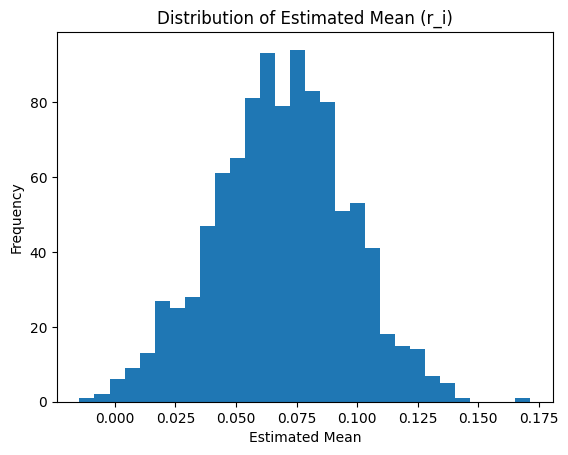

Mean of estimates: 0.06893662490464808
Variance of estimates: 0.000757283182287729
Bias: -0.001063375095351926
Rejection rate: 0.657


In [29]:
import matplotlib.pyplot as plt

# Example: histogram of estimated mean of r_i
mu_r_estimates = mu_estimates[:, 0]

plt.hist(mu_r_estimates, bins=30)
plt.title("Distribution of Estimated Mean (r_i)")
plt.xlabel("Estimated Mean")
plt.ylabel("Frequency")
plt.show()

# Print key summaries
print("Mean of estimates:", np.mean(mu_r_estimates))
print("Variance of estimates:", np.var(mu_r_estimates))
print("Bias:", np.mean(mu_r_estimates) - mu[0])
print("Rejection rate:", rejection_rate)

## Step 9: Draw Conclusions

| Element | Description |
|--------|------------|
| Input | Summary statistics (bias, variance, rejection rate, plots) |
| Action | Evaluate performance of estimator and test |
| Criteria | Bias ≈ 0, low variance, correct size, good power |
| Output | Assessment of reliability |
| Purpose | Determine whether the method works well under the given DGP |

---

### Explanation

Using the summarized results, we assess:

- Whether the estimator is accurate (low bias)  
- Whether it is stable (low variance)  
- Whether the test behaves correctly (size close to $\alpha$)  

---

### Interpretation

- If bias is small → estimator is approximately unbiased  
- If variance is small → estimator is precise  
- If rejection rate ≈ $\alpha$ → test has correct size  

If these conditions hold, the method performs well under the chosen DGP.

---

### Key Insight

Monte Carlo does not estimate reality.

It evaluates whether your **method is reliable** in a controlled environment.

---

### Why this step matters

This is the final goal of Monte Carlo:

- Not to estimate parameters  
- But to validate estimation and inference procedures  

---

### Reference

- Hayashi (2000), Chapter 2  
- Wooldridge (2010), Chapter 4  

In [31]:
print("Monte Carlo Evaluation Summary:")

print("\nBias (mu_r):", np.mean(mu_estimates[:,0]) - mu[0])
print("Variance (mu_r):", np.var(mu_estimates[:,0]))
print("Rejection rate:", rejection_rate)

print("\nConclusion:")
if abs(np.mean(mu_estimates[:,0]) - mu[0]) < 0.01:
    print("Estimator appears approximately unbiased.")
else:
    print("Estimator shows noticeable bias.")

if abs(rejection_rate - 0.05) < 0.02:
    print("Test size appears appropriate.")
else:
    print("Test may be mis-sized.")

Monte Carlo Evaluation Summary:

Bias (mu_r): -0.001063375095351926
Variance (mu_r): 0.000757283182287729
Rejection rate: 0.657

Conclusion:
Estimator appears approximately unbiased.
Test may be mis-sized.


## Step 10: Report and Generalize Findings (Optional)

| Element | Description |
|--------|------------|
| Input | Conclusions from Step 9 |
| Action | Report results and discuss limitations |
| Output | Written conclusions, tables, or figures |
| Purpose | Communicate findings and assess generalizability |

---

### Explanation

Summarize the main findings:

- Does the estimator perform well?  
- Does the test have correct size and good power?  

Discuss limitations:

- Results depend on chosen DGP  
- Performance may differ under alternative settings  

---

### Key Insight

Monte Carlo results are **conditional on the assumed DGP**.

They do not prove universal validity, only performance under specific scenarios.

---

### Why this matters

This step connects simulation results to:

- Research conclusions  
- Methodological justification  

---

### Reference

- Efron & Tibshirani (1993), Chapter 6  
- Gentle (2003), Chapter 2  

In [32]:
## Step 10: Report and Generalize Findings (Optional)

| Element | Description |
|--------|------------|
| Input | Conclusions from Step 9 |
| Action | Report results and discuss limitations |
| Output | Written conclusions, tables, or figures |
| Purpose | Communicate findings and assess generalizability |

---

### Explanation

Summarize the main findings:

- Does the estimator perform well?  
- Does the test have correct size and good power?  

Discuss limitations:

- Results depend on chosen DGP  
- Performance may differ under alternative settings  

---

### Key Insight

Monte Carlo results are **conditional on the assumed DGP**.

They do not prove universal validity, only performance under specific scenarios.

---

### Why this matters

This step connects simulation results to:

- Research conclusions  
- Methodological justification  

---

### Reference

- Efron & Tibshirani (1993), Chapter 6  
- Gentle (2003), Chapter 2  

SyntaxError: invalid syntax (796299223.py, line 3)